# EDA (Exploratory Data Analysis) of BDG dataset
## About BDG (Building Data Genome)

BDG (Building Data Genome) Dataset consists of several data points energy data spaning 2 years, here we are going to use this data to find anomalies in the points and conduct EDA (Exploratory Data Analysis) to find trends and get an idea of the dataset and do some cleaning.

## Loading Libraries

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

## Loading Data

In [9]:
data_path = "C:/Users/Akshay/Desktop/building-energy-anomaly-detection/data/meters/raw/"

df_list = [] 

for file in os.listdir(data_path): 
    if file.endswith('.csv'): 
        df = pd.read_csv(os.path.join(data_path, file)) 
        df_list.append(df)
        df = pd.concat(df_list, ignore_index=True)

df.to_csv('eda.csv', index=False)

## EDA (Exploratory Data Analysis)
Now we conduct EDA on the joined dataset

In [10]:
print(df.head())

             timestamp  Panther_office_Clementine  Panther_lodging_Cora  \
0  2016-01-01 00:00:00                        NaN                   NaN   
1  2016-01-01 01:00:00                        NaN                   NaN   
2  2016-01-01 02:00:00                        NaN                   NaN   
3  2016-01-01 03:00:00                        NaN                   NaN   
4  2016-01-01 04:00:00                        NaN                   NaN   

   Panther_education_Teofila  Panther_education_Jerome  \
0                        NaN                       NaN   
1                        NaN                       NaN   
2                        NaN                       NaN   
3                        NaN                       NaN   
4                        NaN                       NaN   

   Panther_retail_Kristina  Panther_education_Neal  Panther_lodging_Kara  \
0                      NaN                     NaN                   NaN   
1                      NaN                     N

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140352 entries, 0 to 140351
Columns: 1637 entries, timestamp to Panther_office_Gino
dtypes: float64(1636), object(1)
memory usage: 1.7+ GB
None


In [7]:
print(df.describe())

       Panther_office_Clementine  Panther_lodging_Cora  \
count               40820.000000          56575.000000   
mean                   68.224970           1847.617117   
std                   105.456858           2970.758098   
min                     0.000000              0.000000   
25%                     0.000000            116.722500   
50%                    38.024300            378.541000   
75%                    63.573050           1892.705000   
max                  1014.391800          52617.199000   

       Panther_education_Teofila  Panther_education_Jerome  \
count               60284.000000              68252.000000   
mean                  410.036785               3348.868672   
std                   685.176085               4417.861080   
min                     0.000000                  0.000000   
25%                     0.000000                416.395100   
50%                   130.195600                681.373800   
75%                   514.058700           

In [12]:
print(df.columns)

Index(['timestamp', 'Panther_office_Clementine', 'Panther_lodging_Cora',
       'Panther_education_Teofila', 'Panther_education_Jerome',
       'Panther_retail_Kristina', 'Panther_education_Neal',
       'Panther_lodging_Kara', 'Panther_office_Garth',
       'Panther_office_Lavinia',
       ...
       'Cockatoo_education_Noah', 'Panther_other_Luis', 'Panther_other_Ismael',
       'Panther_education_Jarrett', 'Panther_education_Guillermina',
       'Panther_lodging_Alyssa', 'Panther_retail_Jeanette',
       'Panther_office_Bryce', 'Panther_lodging_Carroll',
       'Panther_office_Gino'],
      dtype='object', length=1637)


## Visualizations

### 2. Distribution Plot - Histogram of Energy Consumption

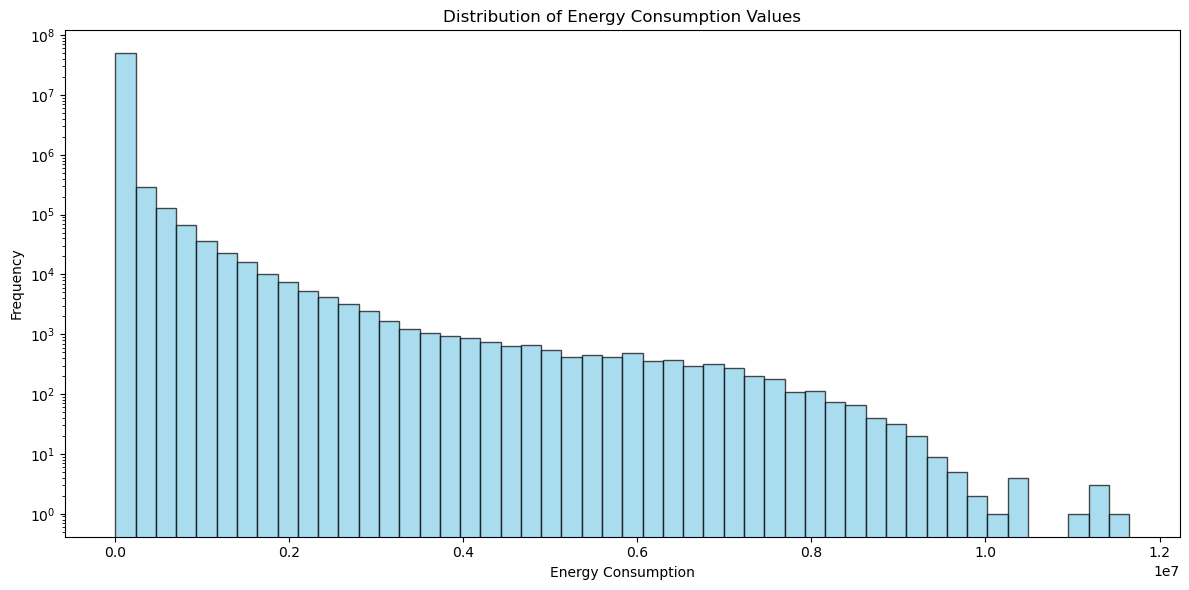

In [14]:
# Flatten all building values for distribution plot
all_values = df.iloc[:, 1:].values.flatten()
all_values = all_values[~np.isnan(all_values)]  # Remove NaN values

plt.figure(figsize=(12, 6))
plt.hist(all_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Energy Consumption Values')
plt.xlabel('Energy Consumption')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale due to wide range of values
plt.tight_layout()
plt.show()

### 3. Box Plot - Energy Consumption by Building Type

C:\Users\Akshay\AppData\Local\Temp\ipykernel_10512\1696970342.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels)


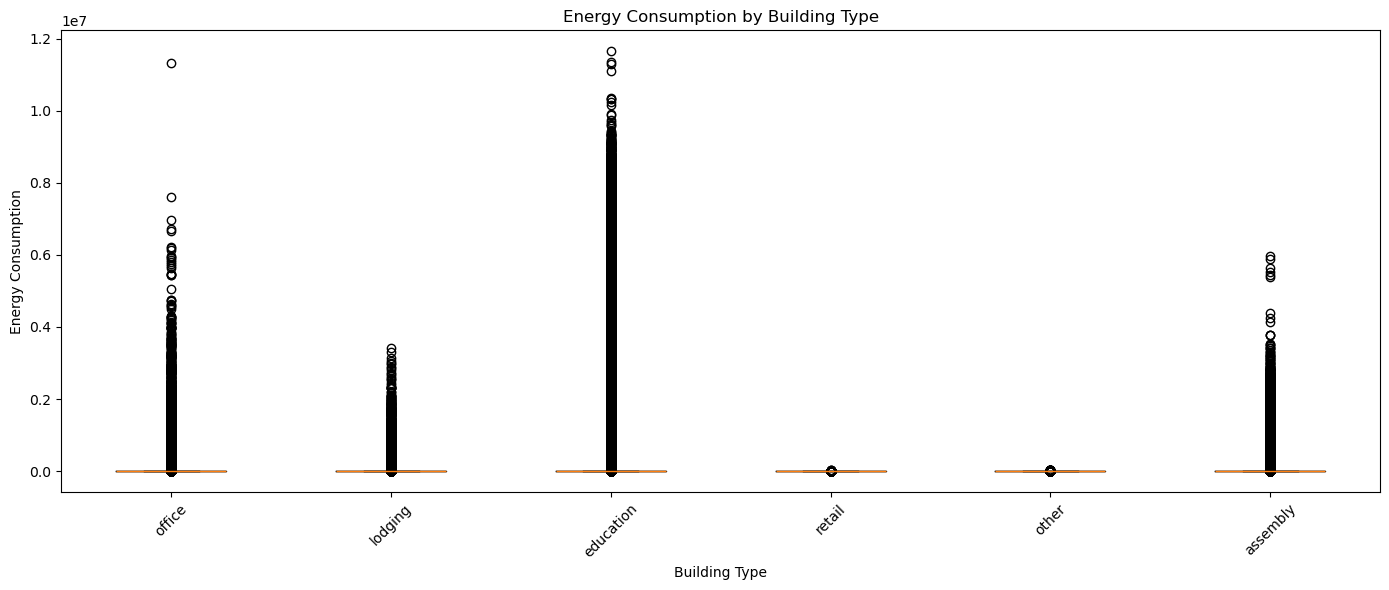

In [15]:
# Extract building types from column names
building_types = {}
for col in df.columns[1:]:
    if '_' in col:
        btype = col.split('_')[1]
        building_types[btype] = building_types.get(btype, []) + [col]

# Create box plot for top building types
top_types = list(building_types.keys())[:6]  # Top 6 building types
plt.figure(figsize=(14, 6))
box_data = []
labels = []
for btype in top_types:
    if building_types[btype]:
        values = df[building_types[btype]].values.flatten()
        values = values[~np.isnan(values)]
        if len(values) > 0:
            box_data.append(values)
            labels.append(btype)

plt.boxplot(box_data, labels=labels)
plt.title('Energy Consumption by Building Type')
plt.xlabel('Building Type')
plt.ylabel('Energy Consumption')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4. Heatmap - Correlation Between Buildings (Sample)

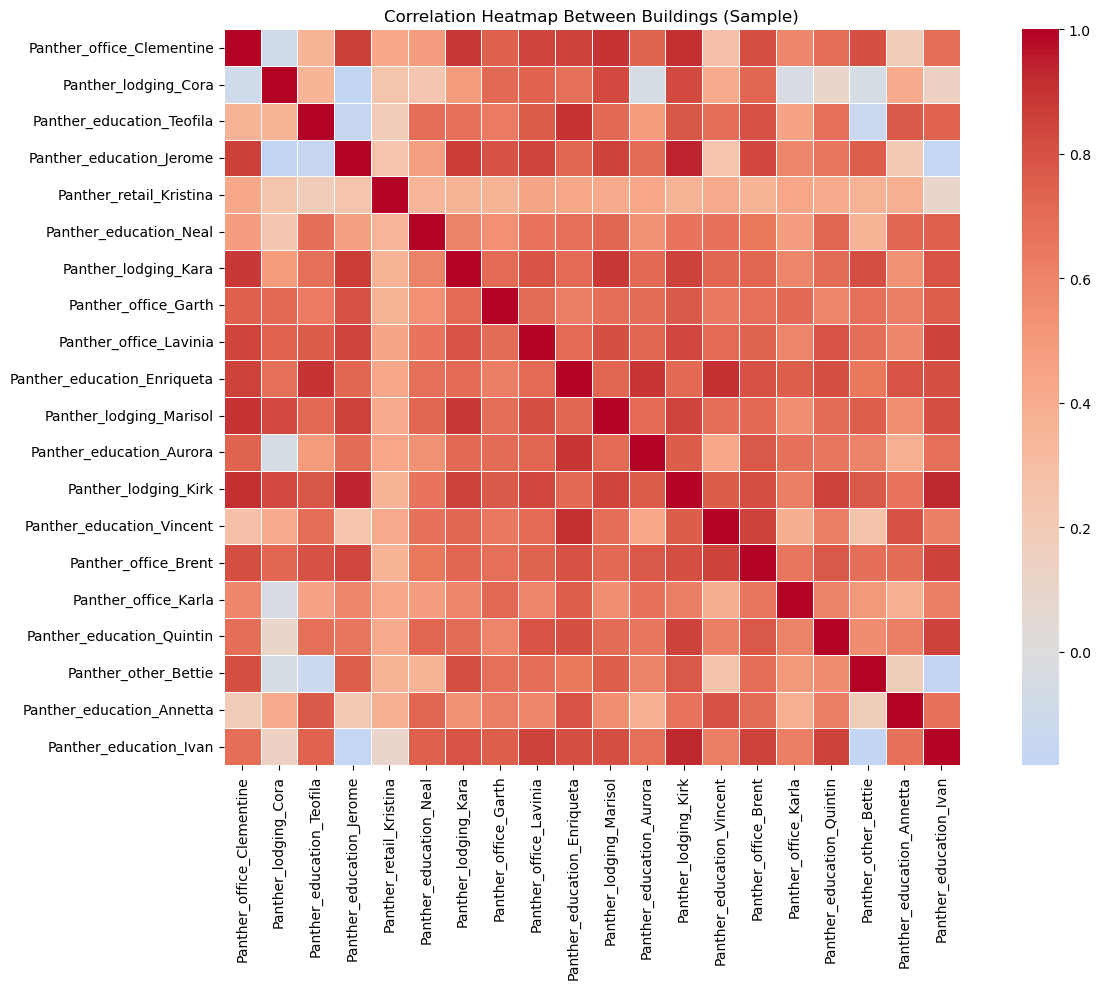

In [16]:
# Select a subset of buildings for correlation
sample_cols = df.columns[1:21]  # First 20 buildings

plt.figure(figsize=(14, 10))
correlation_matrix = df[sample_cols].corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            annot=False, square=True, linewidths=0.5)
plt.title('Correlation Heatmap Between Buildings (Sample)')
plt.tight_layout()
plt.show()

## Outcomes of EDA

We have found the size of the new joined dataset and have a glimpse of the data points and columns, each entry has a "timestamp" that follows YEAR-MONTH-DAY SECONDS-MINUTES-HOURS format, which requires cleaning. 

SIZE OF THE DATASET = 8 rows and 1600+ columns

A small outlier found between 1.0 and 1.2 at the distribution curve of the energy consumption is rather negiligible, hence we dont take that into consideration and move forward for the preprocessing step.